In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [5]:
tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]"
…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]"


In [4]:
from primary.preprocessing import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, tracks=tracks, calo_hits=calo_hits, num_of_events=100)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 444447 depositors.
Preparing lineage map...
Converged after 5 iterations.
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 100 events. Time: 0.06s
Workload optimized: 100 events merged into 100 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 27.82s


In [5]:
target_particles = preprocessed['target_particles']
truth_particles = preprocessed['truth_particles']
calo_clusters = preprocessed['calo_clusters']
tracks = preprocessed['tracks']

In [8]:
target_particles

event_id,particle_id,pdg_id,energy,eta,phi,px,py,pz,charge,mass,has_track
u32,list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[bool]
0,"[85, 88, … 1984]","[211, 2212, … 22]","[0.493202, 3.153299, … 0.187572]","[1.240889, 1.490644, … -0.578707]","[0.896015, -2.707376, … 0.144939]","[0.157703, -1.170844, … 0.158342]","[0.197113, -0.542961, … 0.023112]","[0.400055, 2.71979, … -0.097861]","[1.0, 1.0, … 0.0]","[0.13957, 0.93827, … 0.0]","[false, true, … false]"
1,"[101, 103, … 2823]","[-211, 211, … 2112]","[1.051423, 11.307652, … 1.167582]","[1.648789, 2.776683, … 0.512845]","[1.207647, 0.67892, … -0.545018]","[0.137283, 1.091218, … 0.5225]","[0.361269, 0.880479, … -0.316776]","[0.967806, 11.219516, … 0.32728]","[-1.0, 1.0, … 0.0]","[0.13957, 0.13957, … 0.939565]","[false, true, … false]"
2,"[66, 70, … 3187]","[211, -321, … 22]","[2.031943, 2.858255, … 11.329428]","[0.422144, 0.092224, … -0.738518]","[-0.688222, -0.076493, … 1.583583]","[1.435867, 2.79517, … -0.112707]","[-1.180788, -0.214229, … 8.813717]","[0.808293, 0.258905, … -7.117698]","[1.0, -1.0, … 0.0]","[0.13957, 0.49368, … 0.0]","[true, true, … false]"
3,"[100, 104, … 4204]","[211, 211, … 211]","[12.755524, 1.112025, … 0.835051]","[3.354595, 1.930983, … 0.004287]","[-2.996332, -1.82069, … -2.322416]","[-0.880426, -0.077494, … -0.562166]","[-0.128798, -0.303627, … -0.601488]","[12.723685, 1.057792, … 0.003529]","[1.0, 1.0, … 1.0]","[0.13957, 0.13957, … 0.13957]","[false, false, … false]"
4,"[119, 121, … 2366]","[-211, -211, … 22]","[5.108613, 1.647071, … 0.156006]","[3.001342, 1.804657, … 0.709228]","[1.590296, 1.387508, … -0.60142]","[-0.009877, 0.095835, … 0.101909]","[0.506465, 0.516997, … -0.069933]","[5.08152, 1.554636, … 0.095194]","[-1.0, -1.0, … 0.0]","[0.13957, 0.13957, … 0.0]","[false, false, … false]"
…,…,…,…,…,…,…,…,…,…,…,…
95,"[109, 117, … 3192]","[-321, 321, … 22]","[2.270706, 1.097441, … 4.632338]","[2.342558, 0.246444, … 0.986981]","[2.715917, 0.8102, … -1.313849]","[-0.384352, 0.655646, … 0.770472]","[0.174264, 0.689002, … -2.932279]","[2.175843, 0.236773, … 3.50238]","[-1.0, 1.0, … 0.0]","[0.49368, 0.49368, … 0.0]","[false, true, … false]"
96,"[135, 136, … 5270]","[-211, 211, … -11]","[22.792933, 5.697073, … 0.440079]","[-3.207939, -3.327251, … 1.921398]","[0.909896, -0.589079, … -0.302215]","[1.129715, 0.339487, … 0.120436]","[1.452917, -0.226853, … -0.037548]","[-22.718077, -5.680708, … 0.42161]","[-1.0, 1.0, … 1.0]","[0.13957, 0.13957, … 0.000511]","[false, false, … false]"
97,"[97, 98, … 16584]","[-321, 321, … 22]","[6.044721, 28.769144, … 0.193631]","[3.396099, 2.628725, … -0.530626]","[-0.368797, -0.378601, … 2.984105]","[0.376123, 3.837933, … -0.167146]","[-0.145364, -1.526696, … 0.026543]","[6.011017, 28.466812, … -0.094077]","[-1.0, 1.0, … 0.0]","[0.49368, 0.49368, … 0.0]","[false, true, … false]"


In [9]:
# write preprocessed data to local disk as parquets
file_path = "/storage/agrp/barakma/PileupODD/data"
for key, df in preprocessed.items():
    df.write_parquet(f"{file_path}/preprocessed_{key}.parquet")

In [10]:
# try to see if i can load one of them
cl=pl.read_parquet(f"{file_path}/preprocessed_calo_clusters.parquet")
cl

event_id,cluster_id,total_cluster_energy,cluster_cx,cluster_cy,cluster_cz
u32,list[i32],list[f64],list[f32],list[f32],list[f32]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]"
…,…,…,…,…,…
95,"[0, 1, … 617]","[66.242444, 72.488217, … 0.78129]","[-334.895905, 321.225037, … -2202.310791]","[-215.548737, -1292.880737, … -587.509338]","[-3305.510254, 1501.251709, … 1620.0]"
96,"[0, 1, … 840]","[115.692938, 75.688911, … 0.034788]","[-846.895569, 784.731628, … -2475.934326]","[-1037.897461, 1089.703979, … -2306.22876]","[643.532349, -762.927063, … 1740.0]"
97,"[0, 1, … 991]","[1230.503656, 494.178099, … 0.052503]","[-401.495972, 688.888123, … -2412.5]","[40.472782, -416.98941, … -60.0]","[-3335.438477, -3323.664062, … 630.0]"


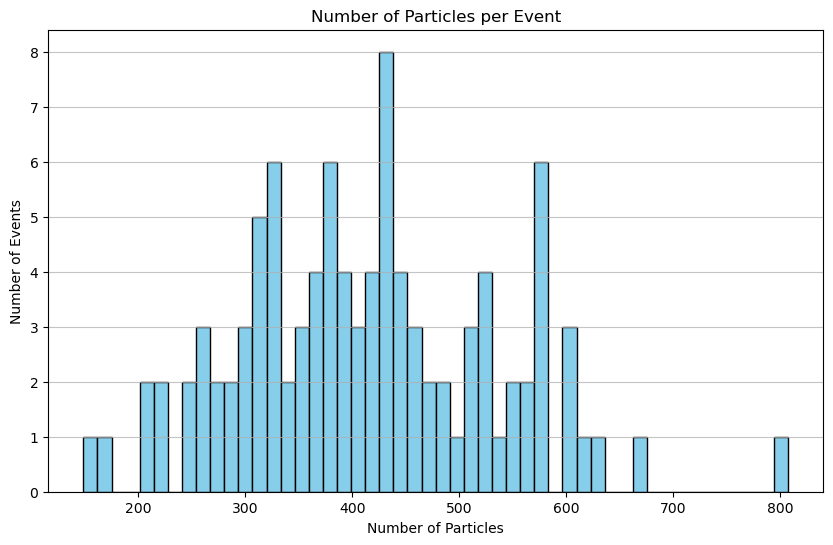

In [9]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = target_particles["particle_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Explode the energy list to get individual particle energies
particle_energies = target_particles["energy"].explode()

plt.figure(figsize=(10, 6))
plt.hist(particle_energies, bins=100, color='salmon', edgecolor='black')
plt.title('Target Particle Energy Distribution')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of Particles')
plt.yscale('log') # Using log scale as energy distributions often span orders of magnitude
plt.grid(axis='y', alpha=0.75)
plt.show()